# 03. LSTM 감성분류기 학습 (비교군)

직접 학습하는 LSTM 베이스라인. DistilBERT와 같은 데이터·지표(Accuracy/F1)로 비교한다.

- 처음부터 학습하는 모델이라 수렴이 느리므로 **최대 15에폭 + val loss 기준 early stopping**(patience 3)으로 학습하고, val 최적 시점의 가중치를 저장한다.
- 튜닝 대상 하이퍼파라미터는 아래 전용 셀에 모아 두었다.

산출물: `models/lstm/{model.pt, vocab.json, metrics.json}`

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import copy
import json
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from src.config import DATA_DIR, MODEL_DIR, OUTPUT_DIR, RANDOM_SEED
from src.models.dataset import build_vocab, encode
from src.models.lstm import LSTMClassifier

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(RANDOM_SEED)

## 하이퍼파라미터

튜닝할 때는 이 셀만 수정하면 된다.

| 변수 | 의미 | 튜닝 가이드 |
|---|---|---|
| `MAX_EPOCHS` / `PATIENCE` | 최대 에폭 / val loss 개선 없을 때 허용 에폭 | patience 내 개선 없으면 조기 종료 |
| `BATCH_SIZE` / `LR` | 배치 크기 / 학습률 | LR은 3e-4 ~ 3e-3 범위 탐색 |
| `SEQ_MAX_LEN` | 입력 시퀀스 최대 토큰 수 | 길수록 느리고 메모리↑ |
| `EMBED_DIM` / `HIDDEN` | 임베딩 / LSTM 은닉 차원 | 모델 용량 |
| `MIN_FREQ` | 어휘 최소 등장 횟수 | 높이면 어휘↓, OOV↑ |

In [2]:
# ── 학습 하이퍼파라미터 ──────────────────────────────
MAX_EPOCHS = 100       # 최대 에폭 (early stopping으로 조기 종료)
PATIENCE = 10          # val loss 개선 없이 허용할 에폭 수
BATCH_SIZE = 128
LR = 1e-4             # Adam 학습률

# ── 입력/모델 하이퍼파라미터 ─────────────────────────
SEQ_MAX_LEN = 512     # 입력 시퀀스 최대 토큰 수
EMBED_DIM = 100       # 임베딩 차원
HIDDEN = 128          # LSTM 은닉 차원
MIN_FREQ = 2          # 어휘 포함 최소 등장 횟수

In [3]:
tr = pd.read_csv(DATA_DIR / "train.csv")
va = pd.read_csv(DATA_DIR / "val.csv")
te = pd.read_csv(DATA_DIR / "test.csv")
vocab = build_vocab(tr["text"].tolist(), min_freq=MIN_FREQ)
print(f"train={len(tr)} val={len(va)} test={len(te)} vocab={len(vocab):,}")

train=5686 val=1218 test=1219 vocab=10,843


In [4]:
def tensors(df, vocab):
    X = torch.tensor([encode(t, vocab, SEQ_MAX_LEN) for t in df["text"]])
    y = torch.tensor(df["label"].tolist())
    return TensorDataset(X, y)

dl = DataLoader(tensors(tr, vocab), batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(tensors(va, vocab), batch_size=BATCH_SIZE)
model = LSTMClassifier(len(vocab), embed_dim=EMBED_DIM, hidden=HIDDEN)
opt = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = torch.nn.CrossEntropyLoss()

@torch.no_grad()
def val_loss():
    model.eval()
    total = sum(loss_fn(model(X), y).item() * len(y) for X, y in val_dl)
    return total / len(va)

batch_losses, epoch_losses, val_losses = [], [], []
best_val, best_state, wait = float("inf"), None, 0
for ep in range(MAX_EPOCHS):
    model.train()
    total = 0.0
    for X, y in dl:
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
        batch_losses.append(loss.item())
        total += loss.item() * len(y)
    epoch_losses.append(total / len(tr))
    val_losses.append(val_loss())
    print(f"epoch {ep + 1}/{MAX_EPOCHS} — train {epoch_losses[-1]:.4f} / val {val_losses[-1]:.4f}")

    if val_losses[-1] < best_val:
        best_val, best_state, wait = val_losses[-1], copy.deepcopy(model.state_dict()), 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"early stopping — {PATIENCE}에폭 연속 val loss 미개선")
            break

model.load_state_dict(best_state)   # val 최적 시점 가중치 복원
print(f"best val loss = {best_val:.4f} (epoch {val_losses.index(best_val) + 1})")

epoch 1/100 — train 0.6879 / val 0.6885
epoch 2/100 — train 0.6810 / val 0.6838
epoch 3/100 — train 0.6762 / val 0.6806
epoch 4/100 — train 0.6710 / val 0.6765
epoch 5/100 — train 0.6645 / val 0.6725
epoch 6/100 — train 0.6551 / val 0.6661
epoch 7/100 — train 0.6372 / val 0.6545
epoch 8/100 — train 0.6044 / val 0.6279
epoch 9/100 — train 0.5669 / val 0.5908
epoch 10/100 — train 0.5328 / val 0.5679
epoch 11/100 — train 0.5087 / val 0.5439
epoch 12/100 — train 0.4904 / val 0.5344
epoch 13/100 — train 0.4688 / val 0.5278
epoch 14/100 — train 0.4579 / val 0.5204
epoch 15/100 — train 0.4372 / val 0.5143
epoch 16/100 — train 0.4228 / val 0.5256
epoch 17/100 — train 0.4063 / val 0.5183
epoch 18/100 — train 0.3922 / val 0.5070
epoch 19/100 — train 0.3846 / val 0.5080
epoch 20/100 — train 0.3737 / val 0.5205
epoch 21/100 — train 0.3617 / val 0.5013
epoch 22/100 — train 0.3432 / val 0.5217
epoch 23/100 — train 0.3337 / val 0.5290
epoch 24/100 — train 0.3277 / val 0.5221
epoch 25/100 — train 0.31

In [5]:
model.eval()
Xte = torch.tensor([encode(t, vocab, SEQ_MAX_LEN) for t in te["text"]])
with torch.no_grad():
    preds = model(Xte).argmax(1).tolist()

result = {"accuracy": accuracy_score(te["label"], preds),
          "f1": f1_score(te["label"], preds)}
print("LSTM test:", result)
print("confusion matrix:\n", confusion_matrix(te["label"], preds))

LSTM test: {'accuracy': 0.7629204265791633, 'f1': 0.753202391118702}
confusion matrix:
 [[489 114]
 [175 441]]


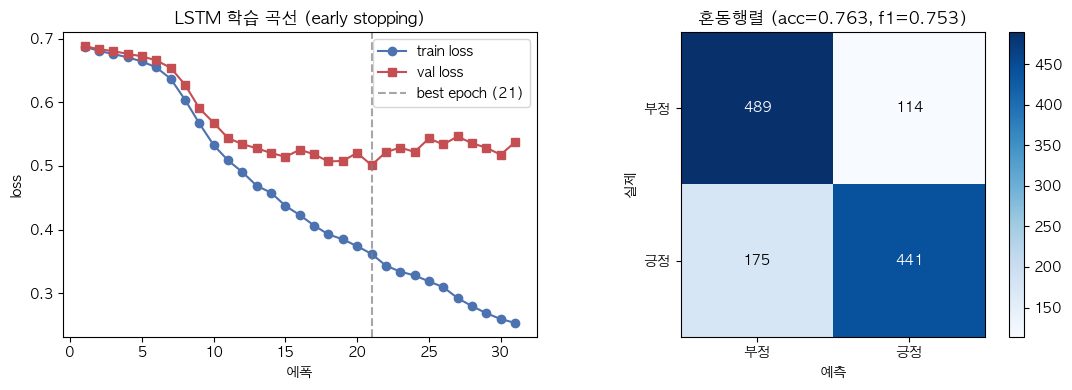

In [6]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

xs = range(1, len(epoch_losses) + 1)
ax1.plot(xs, epoch_losses, "o-", color="#4c72b0", label="train loss")
ax1.plot(xs, val_losses, "s-", color="#c44e52", label="val loss")
best_ep = val_losses.index(min(val_losses)) + 1
ax1.axvline(best_ep, ls="--", color="gray", alpha=0.7, label=f"best epoch ({best_ep})")
ax1.set_title("LSTM 학습 곡선 (early stopping)")
ax1.set_xlabel("에폭")
ax1.set_ylabel("loss")
ax1.legend()

cm = confusion_matrix(te["label"], preds)
im = ax2.imshow(cm, cmap="Blues")
ax2.set_xticks([0, 1], ["부정", "긍정"])
ax2.set_yticks([0, 1], ["부정", "긍정"])
ax2.set_xlabel("예측")
ax2.set_ylabel("실제")
ax2.set_title(f"혼동행렬 (acc={result['accuracy']:.3f}, f1={result['f1']:.3f})")
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, ax=ax2)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "03_lstm_loss_confusion_v2.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
out = MODEL_DIR / "lstm"
out.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), out / "model.pt")
(out / "vocab.json").write_text(json.dumps(vocab))
(out / "metrics.json").write_text(json.dumps(result, indent=2))
print(f"saved → {out}")

saved → /Users/gomuseo/Desktop/Python/review-check/models/lstm


## 추가 베이스라인 — TF-IDF + 로지스틱 회귀

사전학습 없는 **고전 ML 대조군**. 비교 구도가 "고전 ML → 비사전학습 DL(LSTM) → 사전학습 DL(DistilBERT)" 3단이 된다.
이 데이터 규모(train 수천 건)에서는 TF-IDF + 선형 모델이 LSTM과 대등하거나 더 강한 경우가 많다.

산출물: `models/tfidf_logreg/metrics.json` (05 비교 노트북이 읽음), 계수 차트

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# ── TF-IDF + 로지스틱 회귀 하이퍼파라미터 ────────────
TFIDF_MAX_FEATURES = 30000   # 어휘 상한
TFIDF_NGRAM = (1, 2)         # 유니그램 + 바이그램 ("not good" 같은 부정 표현 포착)
LOGREG_C = 1.0               # 역정규화 강도 (작을수록 정규화 강함)

vec = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES,
                      ngram_range=TFIDF_NGRAM, sublinear_tf=True)
Xtr_tfidf = vec.fit_transform(tr["text"])
Xte_tfidf = vec.transform(te["text"])

clf = LogisticRegression(C=LOGREG_C, max_iter=1000, random_state=RANDOM_SEED)
clf.fit(Xtr_tfidf, tr["label"])
preds_lr = clf.predict(Xte_tfidf)

result_lr = {"accuracy": accuracy_score(te["label"], preds_lr),
             "f1": f1_score(te["label"], preds_lr)}
print("TF-IDF+LogReg test:", result_lr)
print("confusion matrix:\n", confusion_matrix(te["label"], preds_lr))

out_lr = MODEL_DIR / "tfidf_logreg"
out_lr.mkdir(parents=True, exist_ok=True)
(out_lr / "metrics.json").write_text(json.dumps(result_lr, indent=2))
print(f"saved → {out_lr}")

TF-IDF+LogReg test: {'accuracy': 0.8178835110746514, 'f1': 0.8125}
confusion matrix:
 [[516  87]
 [135 481]]
saved → /Users/gomuseo/Desktop/Python/review-check/models/tfidf_logreg


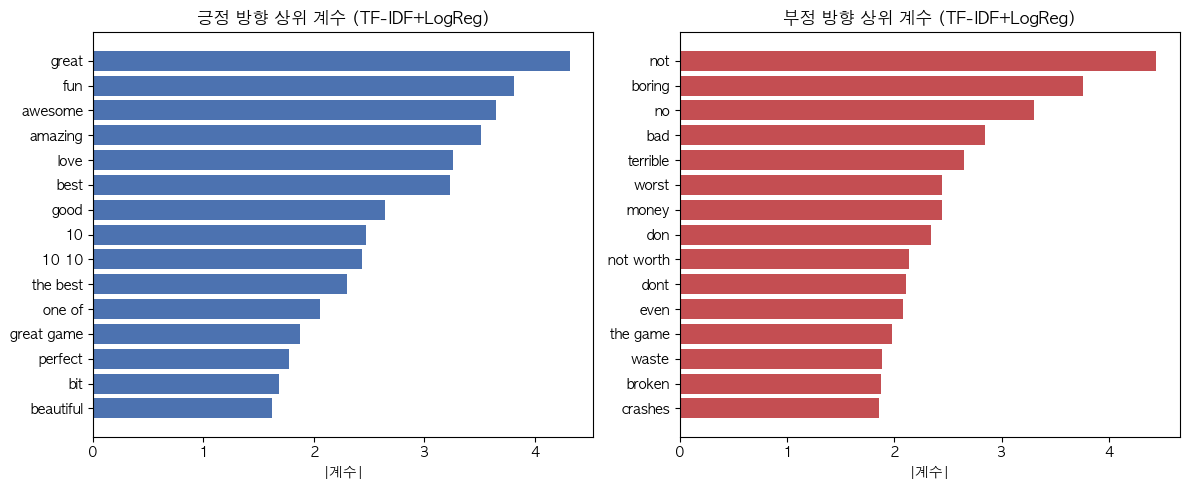

In [11]:
# 로지스틱 회귀 계수 상위 피처 — 선형 모델의 해석 가능성 (로그오즈비 분석과 교차 확인)
import numpy as np

feats = np.array(vec.get_feature_names_out())
coefs = clf.coef_[0]
top_pos_idx = coefs.argsort()[-15:][::-1]
top_neg_idx = coefs.argsort()[:15]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (idx, name, color) in zip(axes, [(top_pos_idx, "긍정", "#4c72b0"),
                                         (top_neg_idx, "부정", "#c44e52")]):
    ax.barh(range(len(idx)), np.abs(coefs[idx]), color=color)
    ax.set_yticks(range(len(idx)), feats[idx])
    ax.invert_yaxis()
    ax.set_title(f"{name} 방향 상위 계수 (TF-IDF+LogReg)")
    ax.set_xlabel("|계수|")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "03_tfidf_logreg_coefs.png", dpi=150, bbox_inches="tight")
plt.show()

## 학습 곡선 — 데이터 크기에 따른 성능 변화

train을 1k/2k/4k/전체로 잘라 각각 학습해 **데이터가 늘수록 누가 얼마나 이득을 보는가**를 본다.

- LSTM(비사전학습)은 임베딩부터 새로 배우므로 데이터 증가의 수혜가 큼
- TF-IDF+LogReg는 적은 데이터에서도 안정적
- DistilBERT는 사전학습 덕에 소량으로도 포화 성능 (참고선)

LSTM을 4회 학습하므로 **수 분 소요**. 산출물: `03_learning_curve.{png,csv}`

In [12]:
SIZES = [1000, 2000, 4000, len(tr)]

def lstm_test_acc(df_sub):
    """부분 train으로 어휘 구축부터 다시 학습 → test accuracy (early stopping 동일 적용)"""
    v = build_vocab(df_sub["text"].tolist(), min_freq=MIN_FREQ)
    dl_s = DataLoader(tensors(df_sub, v), batch_size=BATCH_SIZE, shuffle=True)
    val_s = DataLoader(tensors(va, v), batch_size=BATCH_SIZE)
    m = LSTMClassifier(len(v), embed_dim=EMBED_DIM, hidden=HIDDEN)
    o = torch.optim.Adam(m.parameters(), lr=LR)
    best, best_st, wait = float("inf"), None, 0
    for ep in range(MAX_EPOCHS):
        m.train()
        for X, y in dl_s:
            o.zero_grad()
            loss_fn(m(X), y).backward()
            o.step()
        m.eval()
        with torch.no_grad():
            vl = sum(loss_fn(m(X), y).item() * len(y) for X, y in val_s) / len(va)
        if vl < best:
            best, best_st, wait = vl, copy.deepcopy(m.state_dict()), 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    m.load_state_dict(best_st)
    m.eval()
    with torch.no_grad():
        preds_s = torch.cat([m(X).argmax(1) for X, _ in DataLoader(tensors(te, v), batch_size=BATCH_SIZE)])
    return accuracy_score(te["label"], preds_s.tolist())

def tfidf_test_acc(df_sub):
    v = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES,
                        ngram_range=TFIDF_NGRAM, sublinear_tf=True)
    c = LogisticRegression(C=LOGREG_C, max_iter=1000, random_state=RANDOM_SEED)
    c.fit(v.fit_transform(df_sub["text"]), df_sub["label"])
    return accuracy_score(te["label"], c.predict(v.transform(te["text"])))

curve = []
for n in SIZES:
    sub = tr.sample(n, random_state=RANDOM_SEED) if n < len(tr) else tr
    row = {"train 크기": n,
           "LSTM": lstm_test_acc(sub),
           "TF-IDF+LogReg": tfidf_test_acc(sub)}
    curve.append(row)
    print(f"n={n}: LSTM {row['LSTM']:.3f} / TF-IDF {row['TF-IDF+LogReg']:.3f}")

curve_df = pd.DataFrame(curve)
curve_df.to_csv(OUTPUT_DIR / "03_learning_curve.csv", index=False, encoding="utf-8-sig")
curve_df

n=1000: LSTM 0.638 / TF-IDF 0.769
n=2000: LSTM 0.689 / TF-IDF 0.781
n=4000: LSTM 0.730 / TF-IDF 0.811
n=5686: LSTM 0.756 / TF-IDF 0.818


,train 크기,LSTM,TF-IDF+LogReg
0,1000,0.638228,0.768663
1,2000,0.689089,0.780968
2,4000,0.730107,0.810500
3,5686,0.756358,0.817884


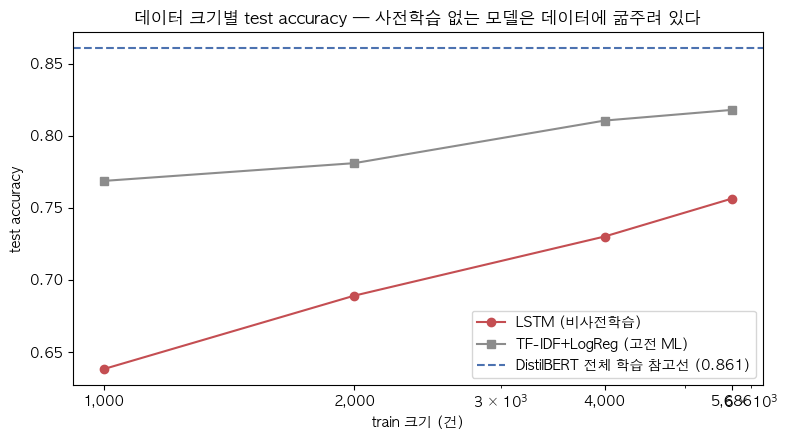

In [13]:
# 학습 곡선 시각화 (+ DistilBERT 참고선)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(curve_df["train 크기"], curve_df["LSTM"], "o-", color="#c44e52", label="LSTM (비사전학습)")
ax.plot(curve_df["train 크기"], curve_df["TF-IDF+LogReg"], "s-", color="#8c8c8c", label="TF-IDF+LogReg (고전 ML)")

bert_metrics = MODEL_DIR / "distilbert" / "metrics.json"
if bert_metrics.exists():
    bert_acc = json.loads(bert_metrics.read_text())["accuracy"]
    ax.axhline(bert_acc, ls="--", color="#4c72b0",
               label=f"DistilBERT 전체 학습 참고선 ({bert_acc:.3f})")

ax.set_title("데이터 크기별 test accuracy — 사전학습 없는 모델은 데이터에 굶주려 있다")
ax.set_xlabel("train 크기 (건)")
ax.set_ylabel("test accuracy")
ax.set_xscale("log")
ax.set_xticks(curve_df["train 크기"], [f"{n:,}" for n in curve_df["train 크기"]])
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "03_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()